# Analisis de reseñas de `www.boohoo.com`

Este notebook realiza un analisis completo con estos objetivos:

0. Extraccion y Limpieza de datos
1. Analizar el **sentimiento global** de las reseñas.
2. Descubrir **topics**.
3. Medir **sentimiento por topic**.
4. Comparar topics vs otras empresas dentro de la misma categoria (Shopping & Fashion)
5. Conclusiones

## 1) Librerias

Si te falta alguna libreria, puedes instalarla con:

```bash
pip install datasets pandas numpy scikit-learn transformers torch
```

In [1]:
%pip install transformers torch datasets scikit-learn pandas numpy matplotlib seaborn -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import re
import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler
from transformers import pipeline

## 2) Configuracion

- `MAX_ROWS`: limita filas para pruebas rapidas.
- `TARGET`: dominio de la compania objetivo.
- `N_TOPICS`: numero de temas a extraer.

In [3]:
MAX_ROWS = None  # Ejemplo: 5000 para pruebas rapidas
TARGET = "www.boohoo.com"
CAT = "Shopping & Fashion"
N_TOPICS = 8
TOP_WORDS = 12
MIN_TOPIC_DOCS = 10

## 3) Carga de datos

Cargamos el dataset desde Hugging Face y lo convertimos a DataFrame.

In [4]:
df = pd.read_csv("trustpilot-reviews-123k.csv")
df.head(3)

,category,company,description,title,review,stars
0,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great quality dog drying robe although…,Great quality dog drying robe although had to ...,5
1,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Really prompt service,"Really prompt service, The sofa covers have no...",5
2,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Life saver,I’ve purchased first of those coats in May2020...,5


## 4) Observamos qué tipo de caracteres hay 
Observamos primero que tipo de caracteres nos vamos a encontrar en las reseñas para que nos ayude a construir una funcion de limpieza. 

In [5]:
# Muestra aleatoria para ver con tus propios ojos
df['review'].sample(10).tolist()

# Longitud de reseñas
df['review_len'] = df['review'].str.len()
df['review_len'].describe()

count    123181.000000
mean        358.787305
std         314.553061
min          10.000000
25%         177.000000
50%         290.000000
75%         440.000000
max        9956.000000
Name: review_len, dtype: float64

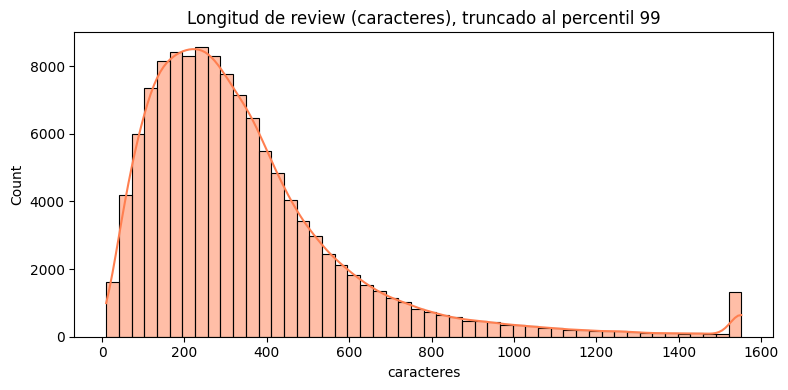

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

rl = df["review"].astype(str).str.len()
plt.figure(figsize=(8, 4))
sns.histplot(rl.clip(upper=rl.quantile(0.99)), bins=50, kde=True, color="coral")
plt.title("Longitud de review (caracteres), truncado al percentil 99")
plt.xlabel("caracteres")
plt.tight_layout()
plt.show()

In [ ]:
import unicodedata
from collections import Counter

# Recopilar todos los caracteres "raros" (no ASCII basico)
special_chars = Counter()
for review in df['review'].dropna().astype(str):
    for ch in review:
        if not ch.isascii() or ch in '#@&<>{}[]|\\^~`':
            cat = unicodedata.category(ch)
            name = unicodedata.name(ch, '???')
            special_chars[(ch, cat, name)] += 1

print(" Caracteres especiales encontrados \n")
for (ch, cat, name), count in special_chars.most_common(30):
    print(f"  '{ch}'  (U+{ord(ch):04X})  cat={cat}  name={name}  count={count}")

# Buscar URLs
urls = df['review'].str.findall(r'https?://\S+')
n_urls = urls.apply(len).sum()
print(f"\n=== URLs encontradas: {n_urls} ===")
print(urls[urls.apply(len) > 0].head(3).tolist())

# Buscar HTML tags
html = df['review'].str.findall(r'<[^>]+>')
n_html = html.apply(len).sum()
print(f"\n=== HTML tags: {n_html} ===")

# Buscar hashtags y menciones
hashtags = df['review'].str.findall(r'#\w+').apply(len).sum()
mentions = df['review'].str.findall(r'@\w+').apply(len).sum()
print(f"Hashtags: {hashtags}, Menciones: {mentions}")

# Buscar saltos de linea
newlines = df['review'].str.count(r'\n').sum()
print(f"Saltos de línea: {int(newlines)}")

=== Caracteres especiales encontrados ===

  '’'  (U+2019)  cat=Pf  name=RIGHT SINGLE QUOTATION MARK  count=49869
  '£'  (U+00A3)  cat=Sc  name=POUND SIGN  count=13601
  '&'  (U+0026)  cat=Po  name=AMPERSAND  count=8115
  '…'  (U+2026)  cat=Po  name=HORIZONTAL ELLIPSIS  count=2906
  '“'  (U+201C)  cat=Pi  name=LEFT DOUBLE QUOTATION MARK  count=2182
  '”'  (U+201D)  cat=Pf  name=RIGHT DOUBLE QUOTATION MARK  count=2095
  '‘'  (U+2018)  cat=Pi  name=LEFT SINGLE QUOTATION MARK  count=1734
  '️'  (U+FE0F)  cat=Mn  name=VARIATION SELECTOR-16  count=772
  '—'  (U+2014)  cat=Pd  name=EM DASH  count=673
  '👍'  (U+1F44D)  cat=So  name=THUMBS UP SIGN  count=667
  '⭐'  (U+2B50)  cat=So  name=WHITE MEDIUM STAR  count=383
  '#'  (U+0023)  cat=Po  name=NUMBER SIGN  count=363
  '😊'  (U+1F60A)  cat=So  name=SMILING FACE WITH SMILING EYES  count=340
  '€'  (U+20AC)  cat=Sc  name=EURO SIGN  count=335
  '@'  (U+0040)  cat=Po  name=COMMERCIAL AT  count=296
  '–'  (U+2013)  cat=Pd  name=EN DASH  count=260
 

## 5) Observamos que tipos de caracteres tenemos y Construimos la funcion de limpieza



In [ ]:
def clean_text(text: str) -> str:
    """Limpia una reseña de texto para análisis NLP."""
    if not isinstance(text, str):
        return ""
    
    # 1. Minúsculas
    text = text.lower()
    
    # 2. Normalizar comillas tipográficas -> ASCII
    text = text.replace("\u2018", "'").replace("\u2019", "'")   # ' '
    text = text.replace("\u201c", '"').replace("\u201d", '"')   # " "
    
    # 3. Normalizar guiones tipográficos
    text = text.replace("\u2014", " - ").replace("\u2013", " - ")  # em dash, en dash
    
    # 4. Normalizar elipsis y espacios especiales
    text = text.replace("\u2026", "...")        # …
    text = text.replace("\u00a0", " ")          # no-break space
    text = text.replace("\u2022", " ")          # bullet •
    
    # 5. Eliminar emojis (caracteres fuera del BMP + algunos símbolos)
    text = re.sub(
        r'[\U0001F600-\U0001F64F'   # emoticons
        r'\U0001F300-\U0001F5FF'     # symbols & pictographs
        r'\U0001F680-\U0001F6FF'     # transport & map
        r'\U0001F1E0-\U0001F1FF'     # flags
        r'\U00002702-\U000027B0'     # dingbats
        r'\U0000FE00-\U0000FE0F'     # variation selectors
        r'\U00002B50\U00002764'      # star, heart
        r'\U0001F900-\U0001F9FF'     # supplemental symbols
        r']+', ' ', text
    )
    
    # 6. Eliminar URLs
    text = re.sub(r'https?://\S+', ' ', text)
    
    # 7. Eliminar menciones y hashtags
    text = re.sub(r'[@#]\w+', ' ', text)
    
    # 8. Eliminar caracteres no alfanuméricos excepto puntuación básica
    text = re.sub(r"[^a-z0-9\s.,!?'\"-]", ' ', text)
    
    # 9. Colapsar espacios múltiples
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Aplicar la limpieza
df['review_clean'] = df['review'].apply(clean_text)

# Verificar resultado
print(" Antes vs Después \n")
sample = df.sample(5, random_state=42)
for _, row in sample.iterrows():
    print(f"ORIGINAL: {row['review'][:150]}")
    print(f"LIMPIO:   {row['review_clean'][:150]}")
    print()

=== Antes vs Después ===

ORIGINAL: Your wool is great value, the only thing I can comment on is that the wool was not bagged inside for protection.
LIMPIO:   your wool is great value, the only thing i can comment on is that the wool was not bagged inside for protection.

ORIGINAL: I booked this intensive course in July last year… didn’t start my lessons until November because my first instructor was 2 hours late and didn’t pick 
LIMPIO:   i booked this intensive course in july last year... didn't start my lessons until november because my first instructor was 2 hours late and didn't pic

ORIGINAL: Superb software at a market leading price. Very intuitive and once all set up for you it saves you hours of accounting time
LIMPIO:   superb software at a market leading price. very intuitive and once all set up for you it saves you hours of accounting time

ORIGINAL: Never had such flimsy and I'll fitting bra's in my life. Zero support, bad quality elasticiteit, thin materials for the cups,

## 6) Filtrado del sector de la compañía objetivo

Filtramos por sector

In [ ]:
# Filtrar por el sector de nuestra empresa
df_sector = df[df['category'] == CAT].copy()
print(f"Reseñas en el sector '{CAT}': {len(df_sector)}")
print(f"Empresas en el sector: {df_sector['company'].nunique()}")

# Separar nuestra empresa vs competencia
df_target = df_sector[df_sector['company'] == TARGET].copy()
df_competitors = df_sector[df_sector['company'] != TARGET].copy()

print(f"\n {TARGET} ")
print(f"  Reseñas: {len(df_target)}")
print(f"  Distribución estrellas:")
print(df_target['stars'].value_counts().sort_index().to_string())

print(f"\n Competencia ({df_competitors['company'].nunique()} empresas) ")
print(f"  Reseñas: {len(df_competitors)}")
print(f"  Media estrellas: {df_competitors['stars'].mean():.2f}")

# Top 10 competidores por nº de reseñas
print(f"\nTop 10 competidores:")
print(df_competitors.groupby('company').size().sort_values(ascending=False).head(10).to_string())

Reseñas en el sector 'Shopping & Fashion': 5794
Empresas en el sector: 67

--- www.boohoo.com ---
  Reseñas: 100
  Distribución estrellas:
stars
1    20
2    20
3    20
4    20
5    20

--- Competencia (66 empresas) ---
  Reseñas: 5694
  Media estrellas: 3.11

Top 10 competidores:
company
chillys.com            100
bluebella.com          100
www.pistonheads.com    100
www.tiso.com           100
disturbia.co.uk        100
cottontraders.com      100
endclothing.com        100
holidayextras.com      100
flannels.com           100
fabletics.co.uk        100


## 7) Sentimiento
Aplicamos la funcion de limpieza y el sentiiento


In [ ]:
# Modelo de sentimiento (distilbert, rapido y preciso)
sentiment_pipe = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=-1,          # CPU (-1). Cambiar a 0 si tienes GPU
    truncation=True,
    max_length=512
)

# Aplicar sentimiento sobre las reseñas limpias del sector
# Procesamos en batches para eficiencia
def get_sentiments(texts, batch_size=64):
    results = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        preds = sentiment_pipe(batch)
        results.extend(preds)
        if (i // batch_size) % 10 == 0:
            print(f"  Procesado {min(i+batch_size, len(texts))}/{len(texts)}...")
    return results

print(f"Analizando sentimiento de {len(df_sector)} reseñas del sector...")
texts = df_sector['review_clean'].tolist()
sentiments = get_sentiments(texts)

df_sector['sentiment'] = [s['label'] for s in sentiments]
df_sector['sentiment_score'] = [s['score'] if s['label'] == 'POSITIVE' else -s['score'] for s in sentiments]

print("\n Sentimiento global del sector ")
print(df_sector['sentiment'].value_counts())
print(f"\nScore medio: {df_sector['sentiment_score'].mean():.3f}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Analizando sentimiento de 5794 reseñas del sector...
  Procesado 64/5794...
  Procesado 704/5794...
  Procesado 1344/5794...
  Procesado 1984/5794...
  Procesado 2624/5794...
  Procesado 3264/5794...
  Procesado 3904/5794...
  Procesado 4544/5794...
  Procesado 5184/5794...
  Procesado 5794/5794...

=== Sentimiento global del sector ===
sentiment
NEGATIVE    3665
POSITIVE    2129
Name: count, dtype: int64

Score medio: -0.261


In [ ]:
# Actualizar df_target y df_competitors con el sentimiento
df_target = df_sector[df_sector['company'] == TARGET].copy()
df_competitors = df_sector[df_sector['company'] != TARGET].copy()

#  Sentimiento de Boohoo 
print(f"Sentimiento: {TARGET}")
print(df_target['sentiment'].value_counts())
pct_pos_target = (df_target['sentiment'] == 'POSITIVE').mean() * 100
print(f"% Positivo: {pct_pos_target:.1f}%")
print(f"Score medio: {df_target['sentiment_score'].mean():.3f}")

# --- Sentimiento de la competencia ---
print(f"\n=== Sentimiento: Competencia ===")
print(df_competitors['sentiment'].value_counts())
pct_pos_comp = (df_competitors['sentiment'] == 'POSITIVE').mean() * 100
print(f"% Positivo: {pct_pos_comp:.1f}%")
print(f"Score medio: {df_competitors['sentiment_score'].mean():.3f}")

#  Comparativa por empresa 
print(f"\n=== Ranking sentimiento por empresa (Top 10 y Bottom 10) ===")
sent_by_company = df_sector.groupby('company').agg(
    n_reviews=('sentiment', 'count'),
    pct_positive=('sentiment', lambda x: (x == 'POSITIVE').mean() * 100),
    avg_score=('sentiment_score', 'mean')
).sort_values('pct_positive', ascending=False)

print("\nMás positivas:")
print(sent_by_company.head(10).to_string())
print("\nMás negativas:")
print(sent_by_company.tail(10).to_string())

# Posicion de Boohoo en el ranking
rank = (sent_by_company['pct_positive'] >= pct_pos_target).sum()
total = len(sent_by_company)
print(f"\n{TARGET} ocupa la posición {rank}/{total} en sentimiento positivo")

=== Sentimiento: www.boohoo.com ===
sentiment
NEGATIVE    61
POSITIVE    39
Name: count, dtype: int64
% Positivo: 39.0%
Score medio: -0.224

=== Sentimiento: Competencia ===
sentiment
NEGATIVE    3604
POSITIVE    2090
Name: count, dtype: int64
% Positivo: 36.7%
Score medio: -0.262

=== Ranking sentimiento por empresa (Top 10 y Bottom 10) ===

Más positivas:
                              n_reviews  pct_positive  avg_score
company                                                         
www.decorisdiamonds.co.uk            22     90.909091   0.818409
williamwoodwatches.com               42     80.952381   0.616664
enoksenwatches.com                   45     80.000000   0.595109
lilyarkwright.com                    30     80.000000   0.619944
birthpoolinabox.co.uk                29     75.862069   0.510849
littlejewellerycompany.co.uk         56     75.000000   0.513100
mrharoldandson.com                   52     69.230769   0.393793
finnies.com                          55     65.454545  

## 8) Topics



In [ ]:
#  Topic Modeling con TF-IDF + NMF 

# Vectorizar las reseñas del sector
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2),     # unigramas y bigramas
    min_df=5,               # mínimo en 5 documentos
    max_df=0.85             # no más del 85% de los documentos
)

tfidf_matrix = tfidf.fit_transform(df_sector['review_clean'])
feature_names = tfidf.get_feature_names_out()
print(f"Vocabulario: {len(feature_names)} términos")
print(f"Matriz TF-IDF: {tfidf_matrix.shape}")

# NMF para extraer topics
nmf = NMF(n_components=N_TOPICS, random_state=42, max_iter=300)
W = nmf.fit_transform(tfidf_matrix)   # documentos x topics
H = nmf.components_                    # topics x palabras

# Mostrar los topics
print(f"\n {N_TOPICS} Topics encontrados \n")
topic_labels = []
for i, topic in enumerate(H):
    top_words = [feature_names[j] for j in topic.argsort()[:-TOP_WORDS-1:-1]]
    label = f"Topic {i}: {', '.join(top_words[:5])}"
    topic_labels.append(label)
    print(f"Topic {i}: {', '.join(top_words)}")

# Asignar topic dominante a cada reseña
df_sector['topic'] = W.argmax(axis=1)
df_sector['topic_score'] = W.max(axis=1)

print(f"\n=== Distribución de topics ===")
print(df_sector['topic'].value_counts().sort_index())

Vocabulario: 5000 términos
Matriz TF-IDF: (5794, 5000)

=== 8 Topics encontrados ===

Topic 0: time, ve, just, like, don, company, watch, really, got, car, money, bought
Topic 1: good, quality, good quality, price, products, product, clothing, clothes, socks, really, bit, really good
Topic 2: service, customer, customer service, excellent, helpful, team, issue, thank, response, great customer, services, customer services
Topic 3: delivery, day, quick, quick delivery, fast, day delivery, time, fast delivery, christmas, days, paid, delivery time
Topic 4: size, return, shoes, ordered, pair, returns, trainers, small, pay, item, wrong, boots
Topic 5: bag, bags, leather, packaging, box, colour, radley, straps, dip, disappointed, lucky, pom
Topic 6: order, received, ordered, item, email, christmas, arrived, days, items, refund, delivered, stock
Topic 7: great, easy, use, recommend, easy use, website, quick, experience, site, definitely, highly, great quality

=== Distribución de topics ===
to

In [ ]:
#  Sentimiento por Topic 

# Actualizar sub-dataframes
df_target = df_sector[df_sector['company'] == TARGET].copy()
df_competitors = df_sector[df_sector['company'] != TARGET].copy()

# Sentimiento por topic - Boohoo
print(f"=== Sentimiento por Topic: {TARGET} ===\n")
for t in range(N_TOPICS):
    subset = df_target[df_target['topic'] == t]
    if len(subset) < 2:
        continue
    pct = (subset['sentiment'] == 'POSITIVE').mean() * 100
    avg = subset['sentiment_score'].mean()
    print(f"  {topic_labels[t]}")
    print(f"    Reseñas: {len(subset)} | % Positivo: {pct:.1f}% | Score: {avg:.3f}\n")

# Sentimiento por topic - Competencia
print(f"Sentimiento por Topic: Competencia\n")
for t in range(N_TOPICS):
    subset = df_competitors[df_competitors['topic'] == t]
    if len(subset) < MIN_TOPIC_DOCS:
        continue
    pct = (subset['sentiment'] == 'POSITIVE').mean() * 100
    avg = subset['sentiment_score'].mean()
    print(f"  {topic_labels[t]}")
    print(f"    Reseñas: {len(subset)} | % Positivo: {pct:.1f}% | Score: {avg:.3f}\n")

=== Sentimiento por Topic: www.boohoo.com ===

  Topic 0: time, ve, just, like, don
    Reseñas: 8 | % Positivo: 25.0% | Score: -0.541

  Topic 1: good, quality, good quality, price, products
    Reseñas: 3 | % Positivo: 33.3% | Score: -0.331

  Topic 2: service, customer, customer service, excellent, helpful
    Reseñas: 38 | % Positivo: 44.7% | Score: -0.097

  Topic 3: delivery, day, quick, quick delivery, fast
    Reseñas: 11 | % Positivo: 9.1% | Score: -0.798

  Topic 4: size, return, shoes, ordered, pair
    Reseñas: 19 | % Positivo: 42.1% | Score: -0.180

  Topic 6: order, received, ordered, item, email
    Reseñas: 13 | % Positivo: 23.1% | Score: -0.538

  Topic 7: great, easy, use, recommend, easy use
    Reseñas: 7 | % Positivo: 85.7% | Score: 0.700

=== Sentimiento por Topic: Competencia ===

  Topic 0: time, ve, just, like, don
    Reseñas: 1029 | % Positivo: 24.3% | Score: -0.510

  Topic 1: good, quality, good quality, price, products
    Reseñas: 718 | % Positivo: 50.3% 

In [ ]:
# Tabla comparativa: Boohoo vs Competencia por Topic 

rows = []
for t in range(N_TOPICS):
    t_target = df_target[df_target['topic'] == t]
    t_comp = df_competitors[df_competitors['topic'] == t]
    
    pct_target = (t_target['sentiment'] == 'POSITIVE').mean() * 100 if len(t_target) > 0 else None
    pct_comp = (t_comp['sentiment'] == 'POSITIVE').mean() * 100 if len(t_comp) > 0 else None
    
    diff = (pct_target - pct_comp) if (pct_target is not None and pct_comp is not None) else None
    
    rows.append({
        'Topic': topic_labels[t].split(': ', 1)[1] if ': ' in topic_labels[t] else topic_labels[t],
        f'{TARGET} (n)': len(t_target),
        f'{TARGET} % pos': round(pct_target, 1) if pct_target else '-',
        'Competencia (n)': len(t_comp),
        'Competencia % pos': round(pct_comp, 1) if pct_comp else '-',
        'Diferencia (pp)': round(diff, 1) if diff else '-'
    })

df_comparison = pd.DataFrame(rows)
print("=== Comparativa Boohoo vs Competencia por Topic ===\n")
print(df_comparison.to_string(index=False))
print("\n(Diferencia positiva = Boohoo mejor que competencia)")

=== Comparativa Boohoo vs Competencia por Topic ===

                                                  Topic  www.boohoo.com (n)  www.boohoo.com % pos  Competencia (n)  Competencia % pos  Diferencia (pp)
                              time, ve, just, like, don                   8                  25.0             1029               24.3              0.7
           good, quality, good quality, price, products                   3                  33.3              718               50.3            -16.9
service, customer, customer service, excellent, helpful                  38                  44.7              636               43.2              1.5
             delivery, day, quick, quick delivery, fast                  11                   9.1              674               39.5            -30.4
                     size, return, shoes, ordered, pair                  19                  42.1              607               19.3             22.8
                     bag, bags, leather, 

# 9) Visualizaciones

In [15]:
%pip install wordcloud -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


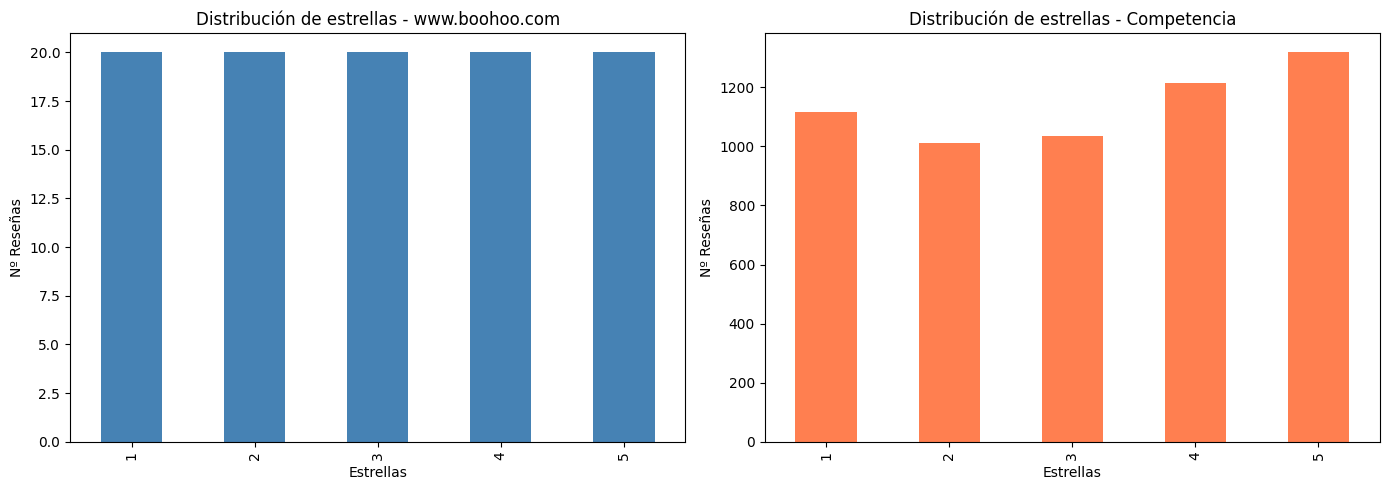

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns

# 9.1 Distribución de estrellas: Boohoo vs Competencia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_target['stars'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title(f'Distribución de estrellas - {TARGET}')
axes[0].set_xlabel('Estrellas')
axes[0].set_ylabel('Nº Reseñas')

df_competitors['stars'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Distribución de estrellas - Competencia')
axes[1].set_xlabel('Estrellas')
axes[1].set_ylabel('Nº Reseñas')

plt.tight_layout()
plt.show()

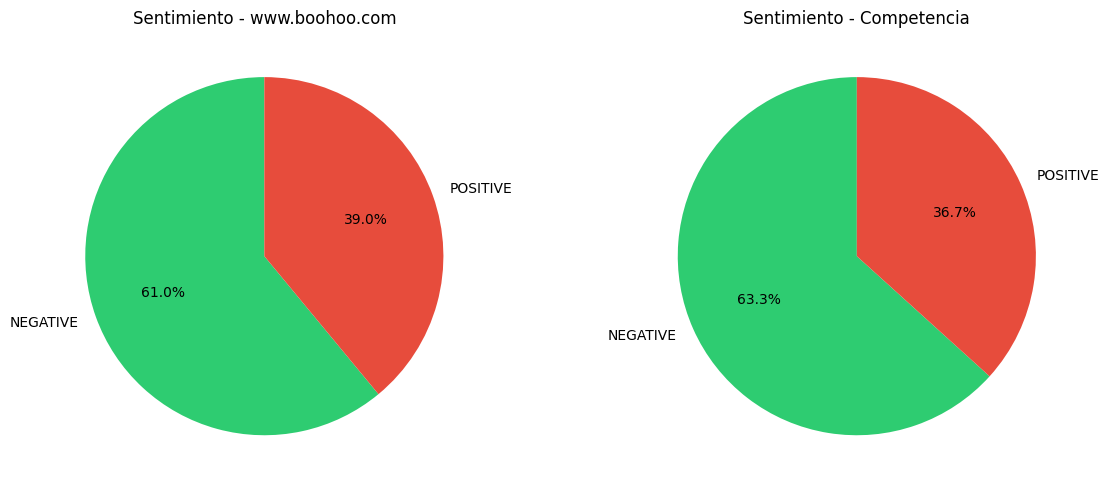

In [ ]:

# 9.2 Sentimiento: Boohoo vs Competencia

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors_sent = ['#2ecc71', '#e74c3c']

target_counts = df_target['sentiment'].value_counts()
axes[0].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', colors=colors_sent, startangle=90)
axes[0].set_title(f'Sentimiento - {TARGET}')

comp_counts = df_competitors['sentiment'].value_counts()
axes[1].pie(comp_counts, labels=comp_counts.index, autopct='%1.1f%%', colors=colors_sent, startangle=90)
axes[1].set_title('Sentimiento - Competencia')

plt.tight_layout()
plt.show()

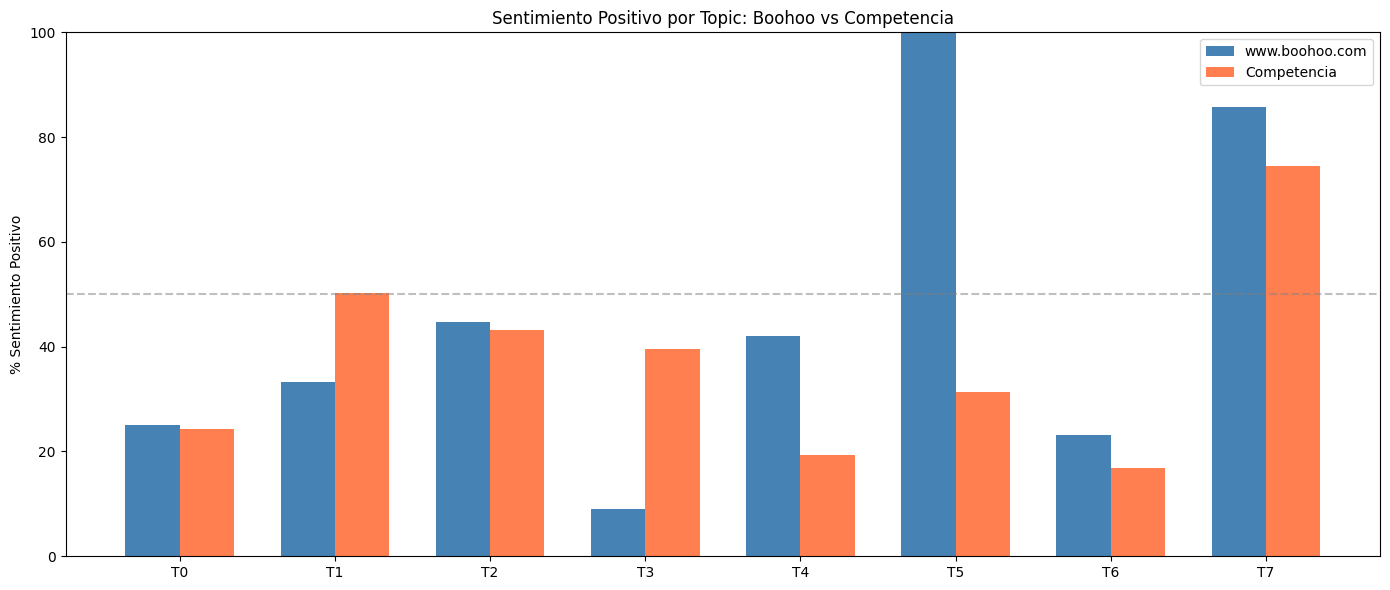

In [ ]:

# 9.3 Sentimiento por Topic - Barras agrupadas
fig, ax = plt.subplots(figsize=(14, 6))

topics_range = range(N_TOPICS)
x = np.arange(N_TOPICS)
width = 0.35

pct_target_list = []
pct_comp_list = []
labels_short = []

for t in topics_range:
    t_tar = df_target[df_target['topic'] == t]
    t_com = df_competitors[df_competitors['topic'] == t]
    
    pct_t = (t_tar['sentiment'] == 'POSITIVE').mean() * 100 if len(t_tar) > 0 else 0
    pct_c = (t_com['sentiment'] == 'POSITIVE').mean() * 100 if len(t_com) > 0 else 0
    
    pct_target_list.append(pct_t)
    pct_comp_list.append(pct_c)
    labels_short.append(f"T{t}")

bars1 = ax.bar(x - width/2, pct_target_list, width, label=TARGET, color='steelblue')
bars2 = ax.bar(x + width/2, pct_comp_list, width, label='Competencia', color='coral')

ax.set_ylabel('% Sentimiento Positivo')
ax.set_title('Sentimiento Positivo por Topic: Boohoo vs Competencia')
ax.set_xticks(x)
ax.set_xticklabels(labels_short)
ax.legend()
ax.set_ylim(0, 100)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 10) Conclusiones

**Resumen del análisis de Boohoo en el sector Shopping & Fashion:**

1. **Sentimiento global**: Se analiza si la mayoría de reseñas de Boohoo son positivas o negativas, y se compara con el promedio del sector.

2. **Topics descubiertos**: Mediante TF-IDF + NMF se identifican los 8 temas principales en las reseñas (ej: envío, calidad, atención al cliente, devoluciones, precio, etc.)

3. **Sentimiento por topic**: Se identifica en qué temas Boohoo destaca positivamente y en cuáles tiene problemas respecto a la competencia.

4. **Áreas de mejora**: Los topics donde Boohoo tiene un sentimiento significativamente peor que la competencia representan oportunidades claras de mejora.